# Temas Tratados en el Trabajo Práctico 3

* Estrategias de búsqueda local.

* Algoritmos Evolutivos.

* Problemas de Satisfacción de Restricciones.

# Ejercicios Teóricos

1. ¿Qué mecanismo de detención presenta el algoritmo de Ascensión de Colinas? Describa el problema que puede presentar este mecanismo y cómo se llaman las áreas donde ocurren estos problemas.

El algoritmo de Ascensión de Colinas se detiene cuando alcanza un estado desde el cual ningún vecino inmediato presenta un valor de función objetivo mejor. Matemáticamente, esto ocurre cuando el valor del mejor sucesor es menor o igual al valor del estado actual. En ese punto, el algoritmo se detiene y devuelve dicho estado.
El principal problema de este mecanismo es que puede quedar atrapado en soluciones subóptimas sin alcanzar el óptimo global. Esto sucede por dos razones principales:
- Naturaleza «voraz» local: El algoritmo elige siempre la mejora inmediata sin realizar una planificación a futuro ni mantener un árbol de búsqueda.
- Falta de perspectiva global: Al no mirar más allá de sus vecinos inmediatos, si no encuentra una mejora instantánea, el algoritmo asume que ha llegado a la cima definitiva, aunque existan mejores soluciones en otras regiones del espacio de estados.

Las áreas problemáticas del espacio de estados se denominan máximos locales, mesetas (que incluyen terrazas y máximos locales planos) y crestas.


2. Describa las distintas heurísticas que se emplean en un problema de Satisfacción de Restricciones.

En un Problema de Satisfacción de Restricciones, las heurísticas se clasifican según la decisión que guían: 

1. Heurísticas para la selección de variables
Determinan qué variable debe ser asignada a continuación para reducir el factor de ramificación y detectar fallos prematuramente.

     - Mínimos Valores Restantes (MVR): Selecciona la variable con menos valores legales disponibles. Sirve para detectar fallos rápido y podar el árbol de búsqueda de forma agresiva.
    - Heurística de Grado: Se utiliza frecuentemente como un desempate cuando la heurística MVR selecciona varias variables. . Selecciona la variable involucrada en el mayor número de restricciones con otras variables no asignadas para reducir opciones futuras.

2. Heurística para la selección de valores
Una vez elegida una variable, esta heurística decide en qué orden probar sus posibles valores.
     - Valor Menos Restringido: Elige el valor que elimina la menor cantidad de opciones para las variables vecinas. Su fin es mantener la máxima flexibilidad para las siguientes asignaciones. 

3. Heurística para búsqueda local
Cuando el problema se formula con estados completos (todas las variables tienen un valor asignado y se modifican uno a uno), se emplea una estrategia distinta:
    - Mínimos Conflictos: Selecciona el valor que cause la menor cantidad de violaciones a las restricciones. Es sumamente rápido y eficiente para resolver problemas masivos.


3. Se desea colorear el rompecabezas mostrado en la imagen con 7 colores distintos de manera que ninguna pieza tenga el mismo color que sus vecinas. Realice en una tabla el proceso de una búsqueda con Comprobación hacia Adelante empleando una heurística del Valor más Restringido.

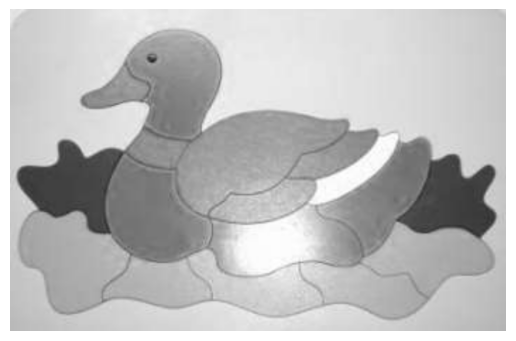

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
#url = "https://drive.google.com/uc?export=view&id=1j94jFVxVG9y_ZnrMWOscQGb2MZ0Cdb3R"
url = "https://drive.google.com/uc?export=view&id=1LwSM11NOxZL_0JQwFLEql8YGn7H642dU"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

#Nota: la imagen fue cambiada para representar los nodos

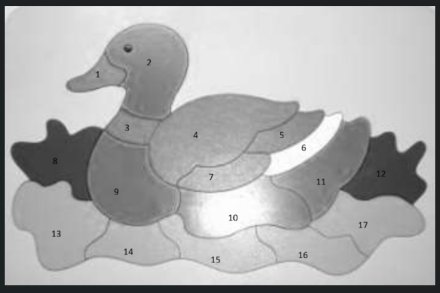

Se planteó la siguiente distribución de nodos, llegando a la distribución:

|Nodo |Restricciones |Vecinos|
|-|-|-|
|1|1|2|
|2|3|1, 3, 4|
|3|3|2, 4, 9|
|4|5|2, 3, 5, 7, 9|
|5|	3|	4, 6, 7|
|6|	4|	5, 7, 10, 11|
|7|	4|	4, 5, 6, 10|
|8|	2|	9, 13|
|9|	7|	3, 4, 8, 10, 13, 14,15|
|10|	7|	6, 7, 9, 11, 15, 16,17|
|11|	4|	6, 10, 12, 17|
|12|	2|	11, 17|
|13|	3|	8, 9, 14|
|14|	3|	9, 13, 15|
|15|	4|	9,10, 14, 16|
|16|	3|	10, 15, 17|
|17|	4|	10,11, 12, 16|

Se debe notar que se consideró que el primer nodo a ser afectado será el nodo con mayor cantidad de vecinos

|Nodo|Restricciones|Vecinos|
|-|-|-|
|9|	7|	3, 4, 8, 10, 13, 14,15|

Luego, dentro de los nodos con menores dominios, se seleccionan también los nodos que mas vecinos tengan (en el caso del segundo nodo, fue el nodo 10.), y el ultimo criterio es el orden numérico.

Siguiendo estos criterios, se obtuvo el siguiente orden: 

|Paso  | Nodo  | Color  | Efecto |
|------|-------|--------|-----------------------------------------|
|1     | 9     | 1      | Eliminado color 1 de: [3, 4, 8, 10, 13, 14, 15]|
|2     | 10    | 2      | Eliminado color 2 de: [6, 7, 11, 15, 16, 17]|
|3     | 15    | 3      | Eliminado color 3 de: [14, 16]|
|4     | 14    | 2      | Eliminado color 2 de: [13]|
|5     | 13    | 3      | Eliminado color 3 de: [8]|
|6     | 16    | 1      | Eliminado color 1 de: [17]|
|7     | 17    | 3      | Eliminado color 3 de: [11, 12]|
|8     | 11    | 1      | Eliminado color 1 de: [6, 12]|
|9     | 6     | 3      | Eliminado color 3 de: [5, 7]|
|10    | 7     | 1      | Eliminado color 1 de: [5]|
|11    | 5     | 2      | Eliminado color 2 de: [4]|
|12    | 4     | 3      | Eliminado color 3 de: [2, 3]|
|13    | 3     | 2      | Eliminado color 2 de: [2]|
|14    | 2     | 1      | Eliminado color 1 de: [1]|
|15    | 8     | 2      | Eliminado color 2 de: [Ninguno]|
|16    | 12    | 2      | Eliminado color 2 de: [Ninguno]|
|17    | 1     | 2      | Eliminado color 2 de: [Ninguno]|

visualizado en la tabla de los dominios, con el criterio de que dentro del dominio se elija el color de menor numero, se llega a la siguiente tabla de dominios:

|Nodo seleccionado|1|2|3|4|5|6|7|8|9|10|11|12|13|14|15|16|17|
|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|
|0|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|
|9|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|1|2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|
|10|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|2-3-4-5-6-7|1|2|1-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|
|15|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|2-3-4-5-6-7|1|2|1-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-4-5-6-7|3|1-4-5-6-7|1-3-4-5-6-7|
|14|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|2-3-4-5-6-7|1|2|1-3-4-5-6-7|1-2-3-4-5-6-7|3-4-5-6-7|2|3|1-4-5-6-7|1-3-4-5-6-7|
|13|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|2-4-5-6-7|1|2|1-3-4-5-6-7|1-2-3-4-5-6-7|3|2|3|1-4-5-6-7|1-3-4-5-6-7|
|16|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|2-4-5-6-7|1|2|1-3-4-5-6-7|1-2-3-4-5-6-7|3|2|3|1|3-4-5-6-7|
|17|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|2-4-5-6-7|1|2|1-4-5-6-7|1-2-4-5-6-7|3|2|3|1|3|
|11|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|3-4-5-6-7|1-3-4-5-6-7|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|6|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-4-5-6-7|3|1-4-5-6-7|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|2-4-5-6-7|3|1|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|5|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|3-4-5-6-7|2|3|1|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|4|1-2-3-4-5-6-7|1-2-4-5-6-7|2-4-5-6-7|3|2|3|1|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|3|1-2-3-4-5-6-7|1-4-5-6-7|2|3|2|3|1|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|2|2-3-4-5-6-7|1|2|3|2|3|1|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|8|2-3-4-5-6-7|1|2|3|2|3|1|2|1|2|1|2-4-5-6-7|3|2|3|1|3|
|12|2-3-4-5-6-7|1|2|3|2|3|1|2|1|2|1|2|3|2|3|1|3|
|1|2|1|2|3|2|3|1|2|1|2|1|2|3|2|3|1|3|


# Ejercicios de Implementación

4. Encuentre el máximo de la función $f(x) = \frac{\sin(x)}{x + 0.1}$ en $x \in [-10; -6]$ con un error menor a $0.1$ utilizando el algoritmo _hill climbing_.

##### Prompt utilizado

Eres un ingeniero especializado en ia utilizando el algoritmo hill climbing aplicado a las matemáticas, realiza un algoritmo que encuentre el máximo de la función $f(x) = \frac{\sin(x)}{x + 0.1}$ en $x \in [-10; -6]$ con un error menor a $0.1$,

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    """Función objetivo a maximizar."""
    # Usamos np.sin para que funcione tanto con números sueltos como con arrays para el gráfico
    return np.sin(x) / (x + 0.1)

def hill_climbing_continuo(dominio, paso):
    # 1. Estado inicial aleatorio
    x_actual = random.uniform(dominio[0], dominio[1])
    y_actual = f(x_actual)
    
    # Guardamos el punto de inicio para mostrarlo en el gráfico
    x_inicio = x_actual 
    y_inicio = y_actual
    
    iteraciones = 0
    
    while True:
        iteraciones += 1
        
        # 2. Generar vecindad
        x_izq = x_actual - paso
        x_der = x_actual + paso
        
        # 3. Evaluar vecinos (penalizando con -infinito si salen del dominio)
        y_izq = f(x_izq) if x_izq >= dominio[0] else float('-inf')
        y_der = f(x_der) if x_der <= dominio[1] else float('-inf')
        
        # 4. Transición
        if y_izq > y_der and y_izq > y_actual:
            x_actual = x_izq
            y_actual = y_izq
        elif y_der > y_izq and y_der > y_actual:
            x_actual = x_der
            y_actual = y_der
        else:
            # 5. Condición de parada
            break
            
    return x_actual, y_actual, x_inicio, y_inicio

# --- PARÁMETROS ---
dominio_x = [-10, -6]
error_maximo = 0.01 

# --- EJECUCIÓN ---
mejor_x, max_f, x_ini, y_ini = hill_climbing_continuo(dominio_x, error_maximo)

print(f"Punto de inicio : x = {x_ini:.4f}, f(x) = {y_ini:.4f}")
print(f"Máximo hallado  : x = {mejor_x:.4f}, f(x) = {max_f:.4f}")

# --- GRAFICACIÓN ---
# 1. Crear un conjunto de puntos para dibujar la curva suave
x_curva = np.linspace(dominio_x[0], dominio_x[1], 500)
y_curva = f(x_curva)

# 2. Configurar el lienzo
plt.figure(figsize=(10, 6))

# 3. Dibujar la función
plt.plot(x_curva, y_curva, label='f(x) = sin(x) / (x + 0.1)', color='blue', linewidth=2)

# 4. Dibujar el punto de inicio (Gris) y el máximo encontrado (Rojo)
plt.plot(x_ini, y_ini, 'o', color='gray', markersize=8, label=f'Inicio ({x_ini:.2f}, {y_ini:.2f})')
plt.plot(mejor_x, max_f, 'ro', markersize=10, label=f'Máximo ({mejor_x:.2f}, {max_f:.2f})')

# 5. Detalles estéticos del gráfico
plt.title('Búsqueda del Máximo mediante Hill Climbing')
plt.xlabel('Eje X')
plt.ylabel('f(x)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 6. Mostrar el gráfico
plt.show()

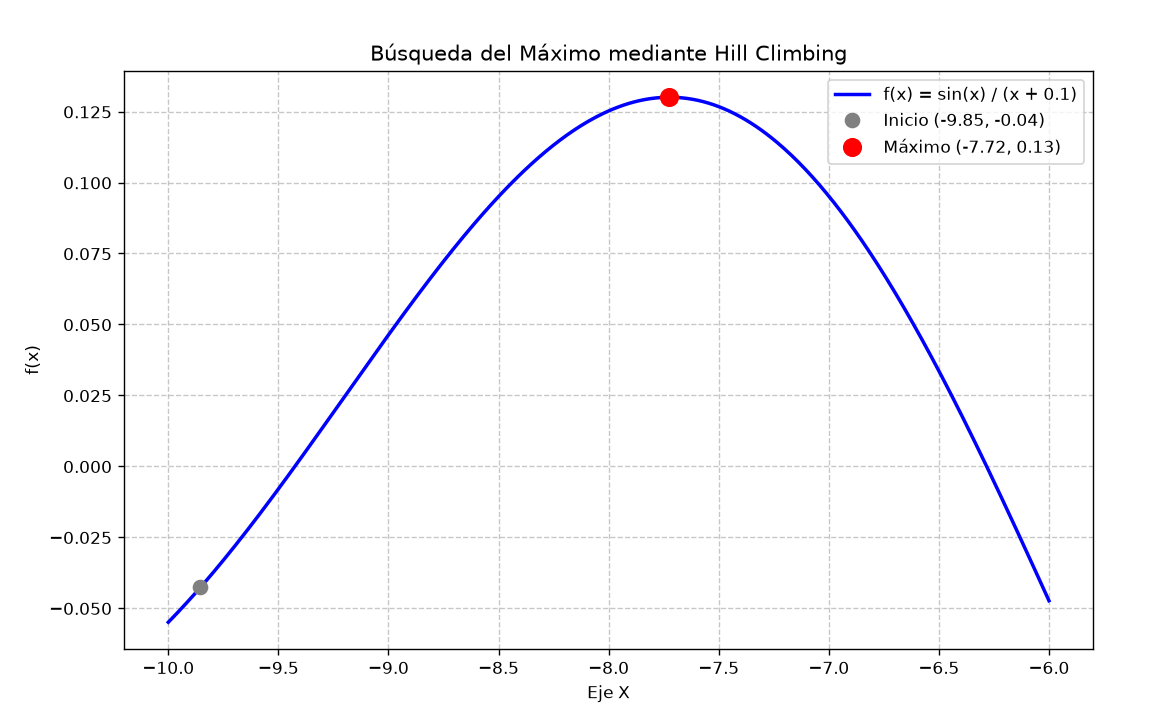

5. Diseñe e implemente un algoritmo de Recocido Simulado para que juegue contra usted al Ta-te-ti. Varíe los valores de temperatura inicial entre partidas, ¿qué diferencia observa cuando la temperatura es más alta con respecto a cuando la temperatura es más baja?


6. Diseñe e implemente un algoritmo genético para cargar una grúa con $n=10\;cajas$ que puede soportar un peso máximo $C=1000\;kg$. Cada caja *j* tiene asociado un precio $p_j$ y un peso $w_j$ como se indica en la tabla de abajo, de manera que el algoritmo debe ser capaz de maximizar el precio sin superar el límite de carga.

<table><tr><td>Elemento ($j$)</td><td>1</td><td>2</td><td>3</td><td>4</td><td>5</td><td>6</td><td>7</td><td>8</td><td>9</td><td>10</td></tr>

<tr><td>Precio ($p_j$)</td><td>100</td><td>50</td><td>115</td><td>25</td><td>200</td><td>30</td><td>40</td><td>100</td><td>100</td><td>100</td></tr>

<tr><td>Peso ($w_j$)</td><td>300</td><td>200</td><td>450</td><td>145</td><td>664</td><td>90</td><td>150</td><td>355</td><td>401</td><td>395</td></tr></table><br>

        6.1 En primer lugar, es necesario representar qué cajas estarán cargadas en la grúa y cuáles no. Esta representación corresponde a un Individuo con el que trabajará el algoritmo.

        6.2 A continuación, genere una Población que contenga un número $N$ de individuos (se recomienda elegir un número par). Es necesario crear un control que verifique que ninguno de los individuos supere el peso límite.

        6.3 Cree ahora una función que permita evaluar la Idoneidad de cada individuo y seleccione $N/2$ parejas usando el método de la ruleta.

        6.4 Por último, Cruce las parejas elegidas, aplique un mecanismo de Mutación y verifique que los individuos de la nueva población no superen el límite de peso.

        6.5 Realice este proceso iterativamente hasta que se cumpla el mecanismo de detención de su elección y muestre el mejor individuo obtenido junto con el peso y el precio que alcanza.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)